# MIPAR Image Measurements

Loads per-FOV image-level measurements from MIPAR batch CSV exports using
`stamp.io.load_mipar_image` and compares key 2-D and 3-D stereological quantities
across multiple material states.

**Contents**
1. Load all material states
2. Inspect the tidy DataFrame
3. 2-D summary tables — phase fraction, particle size, interparticle spacing
4. 2-D box plots per phase (Nature journal style)
5. Derive 3-D stereological quantities — $V_V$, $S_V$, $\bar{D}$, $\lambda_{3D}$
6. 3-D summary tables
7. 3-D box plots per phase (Nature journal style)

In [1]:
%matplotlib inline
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from stamp.io import load_mipar_image
from stamp.export import journal_style, save, to_csv, to_latex, NATURE

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("notebooks/data") if Path.cwd().name != "notebooks" else Path("data")
OUT_DIR = DATA_DIR / "GOO220_image"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FILES = {
    "GOO220_11": DATA_DIR / "GOO220_11_BatchMeas.csv",
    "GOO220_21": DATA_DIR / "GOO220_21_BatchMeas.csv",
    "GOO220_31": DATA_DIR / "GOO220_31_BatchMeas.csv",
    "GOO220_41": DATA_DIR / "GOO220_41_BatchMeas.csv",
    "GOO220_51": DATA_DIR / "GOO220_51_BatchMeas.csv",
    "GOO220_52": DATA_DIR / "GOO220_52_BatchMeas.csv",
    "GOO220_53": DATA_DIR / "GOO220_53_BatchMeas.csv",
}

# Display labels used on plot axes — edit here to switch between time,
# strain %, or any other descriptor without touching the plot cells.
STATE_LABELS = {
    "GOO220_11": "0 kh",
    "GOO220_21": "12 kh",
    "GOO220_31": "51 kh",
    "GOO220_41": "81 kh",
    "GOO220_51": "139 kh gauge",
    "GOO220_52": "139 kh thread",
    "GOO220_53": "139 kh fracture",
}

PHASES = ["M23C6", "MX", "ZPhase", "Laves"]
PHASE_ALIASES = {}

## 1. Load all three material states

Each file contains one row per FOV.  `load_mipar_image` melts the wide-format
table to long format — one row per (FOV × phase) combination.

In [2]:
frames = []
for state, path in FILES.items():
    df = load_mipar_image(path)
    df["Phase"] = df["Phase"].replace(PHASE_ALIASES)
    df.insert(0, "State", state)
    frames.append(df)
    n_fovs = df["Image"].nunique()
    print(f"{state}: {n_fovs} FOVs × {df['Phase'].nunique()} phases → {len(df)} rows")

df_all = pd.concat(frames, ignore_index=True)
print(f"\nCombined: {len(df_all)} rows total")

GOO220_11: 10 FOVs × 4 phases → 40 rows
GOO220_21: 10 FOVs × 4 phases → 40 rows
GOO220_31: 10 FOVs × 4 phases → 40 rows
GOO220_41: 10 FOVs × 4 phases → 40 rows
GOO220_51: 10 FOVs × 4 phases → 40 rows
GOO220_52: 10 FOVs × 4 phases → 40 rows
GOO220_53: 10 FOVs × 4 phases → 40 rows

Combined: 280 rows total


## 2. Inspect the tidy DataFrame

In [3]:
display(df_all.head(12))
print("\nColumns:", df_all.columns.tolist())
print("\nDtypes:")
print(df_all.dtypes)
print("\nMissing values per column:")
print(df_all.isna().sum())

,State,Image,Phase,Area Fraction (%),Image Dim X (um),Image Dim Y (um),Number Density (features/um^2),Mean Intercept - Objects (Random) (um),Mean Intercept - Holes (Random) (um),Mean Inverse Intercept - Objects (Random) (1/um),Mean Inverse Intercept - Holes (Random) (1/um),Mode Intercept - Objects (Random) (um),Mode Intercept - Holes (Random) (um),Mode Inverse Intercept - Objects (Random) (1/um),Mode Inverse Intercept - Holes (Random) (1/um),ASTM Grain Size Number (Random Lines),Total Line Length (Random) (um),Total Intersections (Random)
0,GOO220_11,T3_GOO220_11_Mode2_076_processed.tif,M23C6,3.801,20.61092,13.73949,4.576537,0.073376,1.538282,23.677574,5.903480,0.015,0.15,10.5,1.5,24.2,15021.129513,16629.0
1,GOO220_11,T3_GOO220_11_Mode2_077_processed.tif,M23C6,3.754,20.61092,13.73949,4.138659,0.082293,1.683938,21.785318,5.550623,0.015,0.15,7.5,1.5,23.9,14747.398035,14791.0
2,GOO220_11,T3_GOO220_11_Mode2_078_processed.tif,M23C6,3.876,20.61092,13.73949,4.392911,0.075942,1.555815,23.886421,6.449559,0.025,0.15,7.5,1.5,24.1,14812.998089,16244.0
3,GOO220_11,T3_GOO220_11_Mode2_079_processed.tif,M23C6,4.009,20.61092,13.73949,4.502381,0.083948,1.639096,22.529780,6.060522,0.015,0.15,7.5,1.5,23.8,14729.206678,15165.0
4,GOO220_11,T3_GOO220_11_Mode2_082_processed.tif,M23C6,3.639,20.61092,13.73949,3.909126,0.083555,1.716570,21.485341,5.510148,0.025,0.15,10.5,1.5,23.8,14556.136123,13779.0
5,GOO220_11,T3_GOO220_11_Mode2_083_processed.tif,M23C6,3.147,20.61092,13.73949,5.791297,0.059106,1.485929,26.660674,4.475052,0.035,0.15,13.5,1.0,24.8,14852.951218,17066.0
6,GOO220_11,T3_GOO220_11_Mode2_084_processed.tif,M23C6,3.145,20.61092,13.73949,5.190980,0.063902,1.580277,26.730582,6.750413,0.025,0.15,13.5,1.5,24.6,15052.571831,16403.0
7,GOO220_11,T3_GOO220_11_Mode2_085_processed.tif,M23C6,3.448,20.61092,13.73949,4.901415,0.069242,1.599585,24.469289,4.845154,0.035,0.15,13.5,1.5,24.3,14924.376311,15956.0
8,GOO220_11,T3_GOO220_11_Mode2_086_processed.tif,M23C6,3.541,20.61092,13.73949,5.628858,0.071163,1.544980,24.639495,5.999865,0.035,0.15,10.5,1.5,24.3,15229.349922,16910.0
9,GOO220_11,T3_GOO220_11_Mode2_087_processed.tif,M23C6,3.459,20.61092,13.73949,5.763047,0.064769,1.454391,26.443998,5.601345,0.025,0.15,13.5,1.5,24.5,15445.936800,17972.0



Columns: ['State', 'Image', 'Phase', 'Area Fraction (%)', 'Image Dim X (um)', 'Image Dim Y (um)', 'Number Density (features/um^2)', 'Mean Intercept - Objects (Random) (um)', 'Mean Intercept - Holes (Random) (um)', 'Mean Inverse Intercept - Objects (Random) (1/um)', 'Mean Inverse Intercept - Holes (Random) (1/um)', 'Mode Intercept - Objects (Random) (um)', 'Mode Intercept - Holes (Random) (um)', 'Mode Inverse Intercept - Objects (Random) (1/um)', 'Mode Inverse Intercept - Holes (Random) (1/um)', 'ASTM Grain Size Number (Random Lines)', 'Total Line Length (Random) (um)', 'Total Intersections (Random)']

Dtypes:
State                                                   str
Image                                                   str
Phase                                                   str
Area Fraction (%)                                   float64
Image Dim X (um)                                    float64
Image Dim Y (um)                                    float64
Number Density (featur

## 3. 2-D summary tables

Mean and standard deviation across FOVs for the three key 2-D quantities —
total phase fraction, mean particle size, and 2-D interparticle spacing —
grouped by material state and phase.  Exported as CSV and LaTeX.

In [4]:
# 2-D quantities of interest
PLOT_COLS_2D = {
    "Area Fraction (%)":                       "Phase fraction (%)",
    "Mean Intercept - Objects (Random) (um)":  "Mean particle size — 2D (µm)",
    "Mean Intercept - Holes (Random) (um)":    "Interparticle spacing — 2D (µm)",
}

for phase in PHASES:
    sub = df_all[df_all["Phase"] == phase]
    summary = (
        sub.groupby("State")[list(PLOT_COLS_2D.keys())]
        .agg(["mean", "std"])
        .round(4)
    )
    summary.columns = [f"{PLOT_COLS_2D[m]} ({stat})" for m, stat in summary.columns]
    summary = summary.reset_index()

    print(f"\n── {phase} ──")
    display(summary)

    slug = phase.replace(" ", "_")
    to_csv(summary, OUT_DIR / f"summary_2d_{slug}.csv", decimals=4)
    to_latex(
        summary,
        OUT_DIR / f"summary_2d_{slug}.tex",
        caption=f"2-D per-FOV measurement summary — {phase}.",
        label=f"tab:summary-2d-{slug.lower()}",
        decimals=4,
    )
    print(f"  Saved → {OUT_DIR / f'summary_2d_{slug}.csv'}")


── M23C6 ──


,State,Phase fraction (%) (mean),Phase fraction (%) (std),Mean particle size — 2D (µm) (mean),Mean particle size — 2D (µm) (std),Interparticle spacing — 2D (µm) (mean),Interparticle spacing — 2D (µm) (std)
0,GOO220_11,3.5819,0.2915,0.0727,0.0087,1.5799,0.0827
1,GOO220_21,5.2149,0.4372,0.0943,0.0072,1.4323,0.1429
2,GOO220_31,3.1728,0.5146,0.0846,0.0135,1.9363,0.1386
3,GOO220_41,3.5665,0.3308,0.0927,0.0081,1.9607,0.1204
4,GOO220_51,4.4831,0.1616,0.1240,0.0117,2.0210,0.1343
5,GOO220_52,3.4739,0.3689,0.0898,0.0099,1.8403,0.0840
6,GOO220_53,4.9770,0.3472,0.1315,0.0188,1.9805,0.2663


  Saved → data\GOO220_image\summary_2d_M23C6.csv

── MX ──


,State,Phase fraction (%) (mean),Phase fraction (%) (std),Mean particle size — 2D (µm) (mean),Mean particle size — 2D (µm) (std),Interparticle spacing — 2D (µm) (mean),Interparticle spacing — 2D (µm) (std)
0,GOO220_11,0.2069,0.0254,0.0370,0.0009,4.8591,0.2250
1,GOO220_21,0.1848,0.0196,0.0372,0.0006,4.7648,0.3161
2,GOO220_31,0.1254,0.0301,0.0376,0.0016,5.1342,0.4378
3,GOO220_41,0.1545,0.0221,0.0371,0.0010,5.2447,0.4360
4,GOO220_51,0.0945,0.0210,0.0419,0.0014,5.1973,0.7453
5,GOO220_52,0.1193,0.0192,0.0371,0.0012,5.5243,0.3643
6,GOO220_53,0.0943,0.0198,0.0371,0.0014,5.4682,0.7440


  Saved → data\GOO220_image\summary_2d_MX.csv

── ZPhase ──


,State,Phase fraction (%) (mean),Phase fraction (%) (std),Mean particle size — 2D (µm) (mean),Mean particle size — 2D (µm) (std),Interparticle spacing — 2D (µm) (mean),Interparticle spacing — 2D (µm) (std)
0,GOO220_11,0.0649,0.0131,0.0649,0.0038,4.5701,1.1945
1,GOO220_21,0.0739,0.0133,0.0660,0.0030,5.0684,1.1374
2,GOO220_31,0.0580,0.0268,0.0698,0.0088,5.9658,3.3590
3,GOO220_41,0.1260,0.0283,0.0736,0.0067,4.7653,1.2809
4,GOO220_51,0.3758,0.1024,0.0954,0.0093,4.2711,0.3440
5,GOO220_52,0.1185,0.0500,0.0830,0.0146,3.6560,0.8912
6,GOO220_53,0.2773,0.0632,0.0950,0.0125,4.5928,0.7638


  Saved → data\GOO220_image\summary_2d_ZPhase.csv

── Laves ──


,State,Phase fraction (%) (mean),Phase fraction (%) (std),Mean particle size — 2D (µm) (mean),Mean particle size — 2D (µm) (std),Interparticle spacing — 2D (µm) (mean),Interparticle spacing — 2D (µm) (std)
0,GOO220_11,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,GOO220_21,0.2908,0.1134,0.1954,0.0134,3.4390,1.3293
2,GOO220_31,0.8728,0.3010,0.2440,0.0226,3.9135,0.7569
3,GOO220_41,0.4964,0.2082,0.2357,0.0202,3.6039,0.7883
4,GOO220_51,0.6679,0.2704,0.3111,0.0460,2.7881,0.8831
5,GOO220_52,0.5757,0.2735,0.2672,0.0136,3.2092,1.3779
6,GOO220_53,0.4257,0.1433,0.2849,0.0327,3.1585,1.7245


  Saved → data\GOO220_image\summary_2d_Laves.csv


> **Interpreting "Interparticle spacing — 2D"**
>
> This column is MIPAR’s *Mean Intercept – Holes (Random)*: the mean chord length
> through the **matrix** between successive particle hits along random test lines.
> It is a mean-free-path statistic, not a nearest-neighbour gap.
>
> For **M23C6** (~4–5 % area fraction) the value (~2 µm) is a reasonable proxy
> for the visual gap between particles.
>
> For **MX** (~0.1 %) and **ZPhase** (~0.1–0.4 %), the phase is so dilute that
> most of each test line passes through regions with no particles nearby.
> Those long empty stretches dominate the average, giving ~5 µm for MX even
> though the nearest-neighbour edge-to-edge gap is only ~0.5–0.8 µm
> (estimated as $1/(2\sqrt{\rho}) - d$, where $\rho$ is particle areal density
> and $d$ is mean diameter).
>
> **Use this column for relative trends between states, not as an absolute gap
> measurement — especially for MX and ZPhase.**

## 4. 2-D box plots per phase

For each phase: three panels comparing the three material states —
phase fraction, mean particle size (2-D), and interparticle spacing (2-D).
Rendered in Nature journal style.

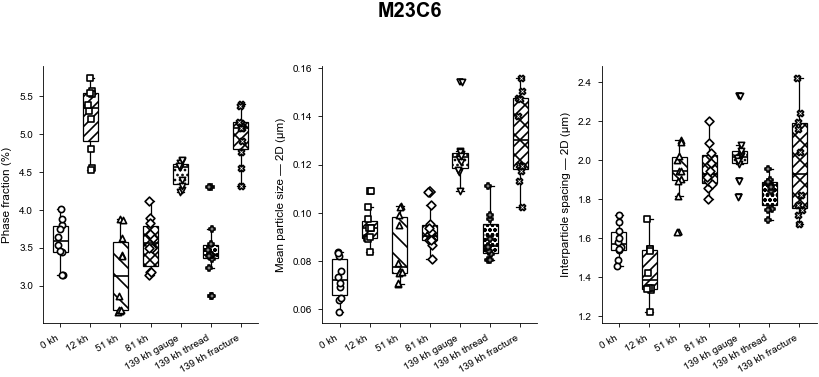

Saved M23C6 → data\GOO220_image


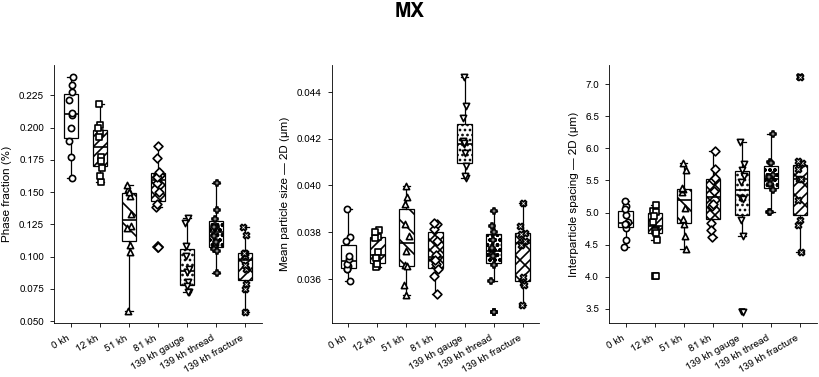

Saved MX → data\GOO220_image


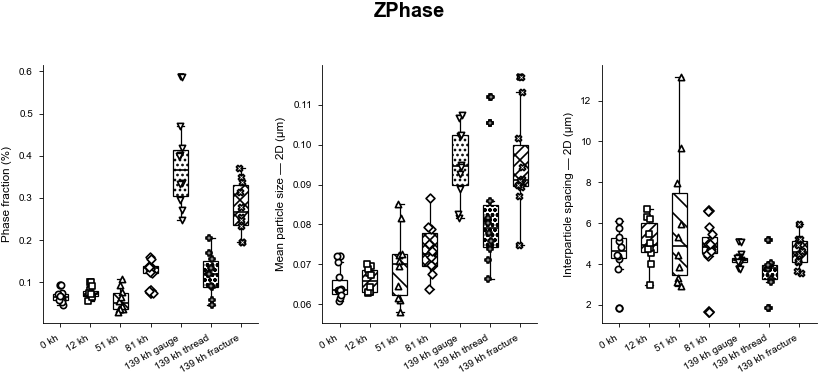

Saved ZPhase → data\GOO220_image


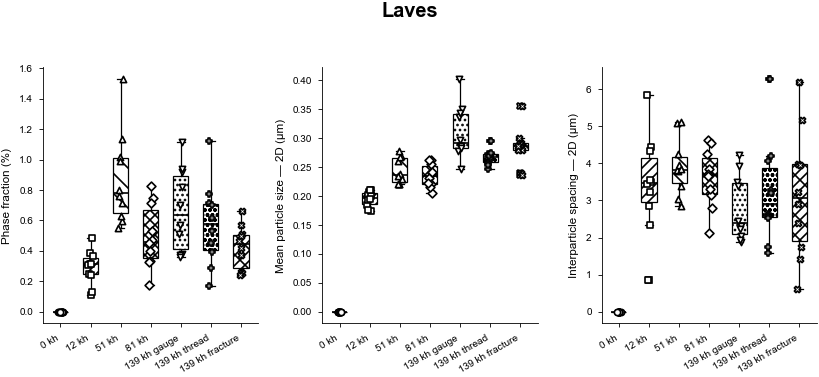

Saved Laves → data\GOO220_image


In [5]:
_BW_HATCHES = ["", "////", "\\\\", "xxxx", "....", "oooo", "////\\\\", "||", "--", "++"]
_BW_MARKERS = ["o", "s", "^", "D", "v", "P", "X", "h", "*", "p"]
STATES = list(FILES.keys())

for phase in PHASES:
    sub = df_all[df_all["Phase"] == phase]

    with journal_style(NATURE):
        fig, axes = plt.subplots(
            1, len(PLOT_COLS_2D),
            figsize=(180 / 25.4, 180 / 25.4 * 0.45),
            sharey=False,
        )
        rng = np.random.default_rng(42)

        for ax, (col, label) in zip(axes, PLOT_COLS_2D.items()):
            for i, state in enumerate(STATES):
                vals = sub[sub["State"] == state][col].dropna().values
                if len(vals) == 0:
                    continue
                ax.boxplot(
                    vals,
                    positions=[i + 1],
                    widths=0.5,
                    patch_artist=True,
                    boxprops=dict(facecolor="white", hatch=_BW_HATCHES[i % len(_BW_HATCHES)], linewidth=0.75),
                    medianprops=dict(color="black", linewidth=1.0),
                    whiskerprops=dict(color="black", linewidth=0.75),
                    capprops=dict(color="black", linewidth=0.75),
                    flierprops=dict(marker=_BW_MARKERS[i % len(_BW_MARKERS)], markerfacecolor="white",
                                   markeredgecolor="black", markersize=4),
                    manage_ticks=False,
                )
                jitter = rng.uniform(-0.08, 0.08, len(vals))
                ax.scatter(i + 1 + jitter, vals, marker=_BW_MARKERS[i % len(_BW_MARKERS)],
                           facecolors="white", edgecolors="black", s=14, zorder=3)

            ax.set_xticks(range(1, len(STATES) + 1))
            ax.set_xticklabels(
                [STATE_LABELS.get(s, s) for s in STATES], rotation=30, ha="right"
            )
            ax.set_ylabel(label)

        fig.suptitle(f"{phase}", fontweight="bold", y=1.02)
        fig.tight_layout()
        slug = phase.replace(" ", "_")
        save(fig, OUT_DIR / f"boxplot_2d_{slug}", formats=["pdf", "png"])
        plt.show()
        print(f"Saved {phase} → {OUT_DIR}")

## 5. Derive 3-D stereological quantities

Apply four image-level stereological relations to each FOV row:

| Quantity | Formula | Reference |
|---|---|---|
| Volume fraction $V_V$ | $V_V = A_A$ | Delesse (1848) |
| Surface area density $S_V$ (µm⁻¹) | $S_V = 4V_V / \bar{L}_\alpha$ | Underwood (1970) |
| Mean caliper diameter $\bar{D}$ (µm) | $\bar{D} = \tfrac{3}{2}\bar{L}_\alpha$ | Fullman (1953) |
| 3-D mean free path $\lambda_{3D}$ (µm) | $\lambda_{3D} = 4(1-V_V)/S_V$ | Underwood (1970) |

In [6]:
from stamp.stereo import (
    mean_caliper_diameter,
    mean_free_path_3d,
    surface_area_density,
    volume_fraction,
)

L_ALPHA = "Mean Intercept - Objects (Random) (um)"

# Zero intercept means the phase was absent in that FOV — 3-D quantities are
# undefined there, so replace with NaN so they propagate cleanly downstream.
df_all[L_ALPHA] = df_all[L_ALPHA].where(df_all[L_ALPHA] > 0)

df_all["V_V"]            = volume_fraction(df_all["Area Fraction (%)"].values)
df_all["S_V (1/um)"]     = surface_area_density(
    df_all["V_V"].values, df_all[L_ALPHA].values
)
df_all["D_bar (um)"]     = mean_caliper_diameter(df_all[L_ALPHA].values)
df_all["lambda_3D (um)"] = mean_free_path_3d(
    df_all["V_V"].values, df_all["S_V (1/um)"].values
)

print("New columns:")
display(df_all[["State", "Phase", "V_V", "S_V (1/um)", "D_bar (um)", "lambda_3D (um)"]].head(12))

New columns:


,State,Phase,V_V,S_V (1/um),D_bar (um),lambda_3D (um)
0,GOO220_11,M23C6,0.03801,2.072067,0.110064,1.857063
1,GOO220_11,M23C6,0.03754,1.824700,0.123440,2.109849
2,GOO220_11,M23C6,0.03876,2.041558,0.113913,1.883346
3,GOO220_11,M23C6,0.04009,1.910230,0.125922,2.010041
4,GOO220_11,M23C6,0.03639,1.742086,0.125333,2.212543
5,GOO220_11,M23C6,0.03147,2.129733,0.088659,1.819064
6,GOO220_11,M23C6,0.03145,1.968639,0.095853,1.967958
7,GOO220_11,M23C6,0.03448,1.991855,0.103863,1.938937
8,GOO220_11,M23C6,0.03541,1.990360,0.106745,1.938524
9,GOO220_11,M23C6,0.03459,2.136207,0.097153,1.807709


## 6. 3-D summary tables

Mean and standard deviation across FOVs for the four 3-D quantities,
grouped by material state and phase.  Exported as CSV and LaTeX.

In [7]:
PLOT_COLS_3D = {
    "V_V":            "Volume fraction V_V",
    "S_V (1/um)":     "Surface area density S_V (1/um)",
    "D_bar (um)":     "Mean caliper diameter D_bar (um)",
    "lambda_3D (um)": "Mean free path lambda_3D (um)",
}

for phase in PHASES:
    sub = df_all[df_all["Phase"] == phase]
    summary = (
        sub.groupby("State")[list(PLOT_COLS_3D.keys())]
        .agg(["mean", "std"])
        .round(4)
    )
    summary.columns = [f"{PLOT_COLS_3D[m]} ({stat})" for m, stat in summary.columns]
    summary = summary.reset_index()

    print()
    print(f"-- {phase} --")
    display(summary)

    slug = phase.replace(" ", "_")
    to_csv(summary, OUT_DIR / f"summary_3d_{slug}.csv", decimals=4)
    to_latex(
        summary,
        OUT_DIR / f"summary_3d_{slug}.tex",
        caption="3-D stereological quantity summary -- " + phase + ".",
        label="tab:summary-3d-" + slug.lower(),
        decimals=4,
    )
    print("  Saved ->", OUT_DIR / ("summary_3d_" + slug + ".csv"))


-- M23C6 --


,State,Volume fraction V_V (mean),Volume fraction V_V (std),Surface area density S_V (1/um) (mean),Surface area density S_V (1/um) (std),Mean caliper diameter D_bar (um) (mean),Mean caliper diameter D_bar (um) (std),Mean free path lambda_3D (um) (mean),Mean free path lambda_3D (um) (std)
0,GOO220_11,0.0358,0.0029,1.9807,0.1270,0.1091,0.0131,1.9545,0.1286
1,GOO220_21,0.0521,0.0044,2.2230,0.2513,0.1415,0.0109,1.7271,0.2135
2,GOO220_31,0.0317,0.0051,1.5012,0.0953,0.1270,0.0202,2.5891,0.1603
3,GOO220_41,0.0357,0.0033,1.5423,0.1163,0.1390,0.0122,2.5150,0.2054
4,GOO220_51,0.0448,0.0016,1.4569,0.1395,0.1860,0.0176,2.6470,0.2866
5,GOO220_52,0.0347,0.0037,1.5565,0.1643,0.1346,0.0148,2.5077,0.2858
6,GOO220_53,0.0498,0.0035,1.5432,0.2429,0.1972,0.0282,2.5242,0.4390


  Saved -> data\GOO220_image\summary_3d_M23C6.csv

-- MX --


,State,Volume fraction V_V (mean),Volume fraction V_V (std),Surface area density S_V (1/um) (mean),Surface area density S_V (1/um) (std),Mean caliper diameter D_bar (um) (mean),Mean caliper diameter D_bar (um) (std),Mean free path lambda_3D (um) (mean),Mean free path lambda_3D (um) (std)
0,GOO220_11,0.0021,0.0003,0.2239,0.0291,0.0555,0.0013,18.1376,2.6746
1,GOO220_21,0.0018,0.0002,0.1986,0.0201,0.0558,0.0009,20.2971,2.0933
2,GOO220_31,0.0013,0.0003,0.1341,0.0341,0.0564,0.0024,32.6718,13.3131
3,GOO220_41,0.0015,0.0002,0.1670,0.0259,0.0556,0.0015,24.5356,4.5402
4,GOO220_51,0.0009,0.0002,0.0903,0.0207,0.0629,0.0021,46.1895,9.5141
5,GOO220_52,0.0012,0.0002,0.1290,0.0239,0.0557,0.0019,31.9082,5.7557
6,GOO220_53,0.0009,0.0002,0.1021,0.0233,0.0556,0.0021,41.3550,11.1568


  Saved -> data\GOO220_image\summary_3d_MX.csv

-- ZPhase --


,State,Volume fraction V_V (mean),Volume fraction V_V (std),Surface area density S_V (1/um) (mean),Surface area density S_V (1/um) (std),Mean caliper diameter D_bar (um) (mean),Mean caliper diameter D_bar (um) (std),Mean free path lambda_3D (um) (mean),Mean free path lambda_3D (um) (std)
0,GOO220_11,0.0006,0.0001,0.0398,0.0066,0.0974,0.0057,102.9181,17.0011
1,GOO220_21,0.0007,0.0001,0.0447,0.0072,0.0990,0.0044,91.4132,14.0617
2,GOO220_31,0.0006,0.0003,0.0326,0.0129,0.1046,0.0132,138.6088,46.7684
3,GOO220_41,0.0013,0.0003,0.0691,0.0166,0.1105,0.0100,62.3526,21.1907
4,GOO220_51,0.0038,0.0010,0.1562,0.0325,0.1430,0.0139,26.4334,5.0069
5,GOO220_52,0.0012,0.0005,0.0554,0.0168,0.1246,0.0220,80.6517,33.0951
6,GOO220_53,0.0028,0.0006,0.1160,0.0163,0.1425,0.0188,35.0451,5.1244


  Saved -> data\GOO220_image\summary_3d_ZPhase.csv

-- Laves --


,State,Volume fraction V_V (mean),Volume fraction V_V (std),Surface area density S_V (1/um) (mean),Surface area density S_V (1/um) (std),Mean caliper diameter D_bar (um) (mean),Mean caliper diameter D_bar (um) (std),Mean free path lambda_3D (um) (mean),Mean free path lambda_3D (um) (std)
0,GOO220_11,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN
1,GOO220_21,0.0029,0.0011,0.0586,0.0209,0.2930,0.0201,79.3520,38.0014
2,GOO220_31,0.0087,0.0030,0.1410,0.0386,0.3661,0.0339,29.8227,7.2625
3,GOO220_41,0.0050,0.0021,0.0823,0.0284,0.3536,0.0302,55.7908,26.7043
4,GOO220_51,0.0067,0.0027,0.0836,0.0248,0.4666,0.0690,51.7684,16.3866
5,GOO220_52,0.0058,0.0027,0.0859,0.0383,0.4008,0.0203,60.1969,39.9779
6,GOO220_53,0.0043,0.0014,0.0597,0.0184,0.4274,0.0491,73.7922,26.1658


  Saved -> data\GOO220_image\summary_3d_Laves.csv


> **Interpreting the 3-D stereological quantities**
>
> All four 3-D quantities are derived from MIPAR's 2-D line-intercept
> measurements via classical stereological relations, and inherit the same
> limitations for dilute phases.
>
> | Quantity | Relation | Assumption |
> |---|---|---|
> | $V_V$ | $V_V = A_A$ | Delesse (1848) — holds for any isotropic section |
> | $S_V$ | $S_V = 4V_V / \bar{L}_\alpha$ | Underwood (1970) — isotropic, convex particles |
> | $\bar{D}$ | $\bar{D} = \tfrac{3}{2}\bar{L}_\alpha$ | Fullman (1953) — spherical particles |
> | $\lambda_{3D}$ | $\lambda_{3D} = 4(1-V_V)/S_V$ | Underwood (1970) — isotropic matrix |
>
> **$V_V$, $S_V$, and $\bar{D}$** are well-behaved across all phases and
> track real microstructural changes reliably.
>
> **$\lambda_{3D}$ (3-D mean free path)** has the same interpretation issue
> as the 2-D interparticle spacing: for dilute phases it is dominated by
> the long stretches of matrix between rare particle encounters along a test
> line. For **MX** (~0.1 % $V_V$) and **ZPhase** (~0.1–0.4 % $V_V$) the
> reported values reach 30–80 µm — far larger than any visually apparent
> gap — because the 3-D matrix occupies >99 % of the volume.
> Use $\lambda_{3D}$ for **relative trends between states only**, not as an
> absolute measure of the gap between individual particles for these phases.

## 7. 3-D box plots per phase

For each phase: four panels comparing the three material states.
Rendered in Nature journal style.

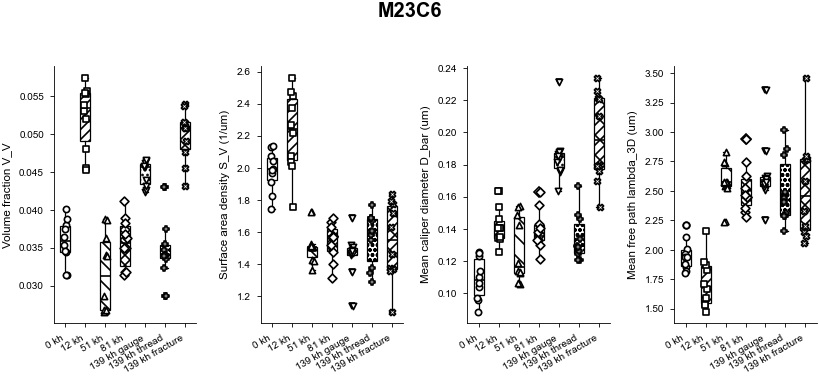

Saved M23C6 -> data\GOO220_image


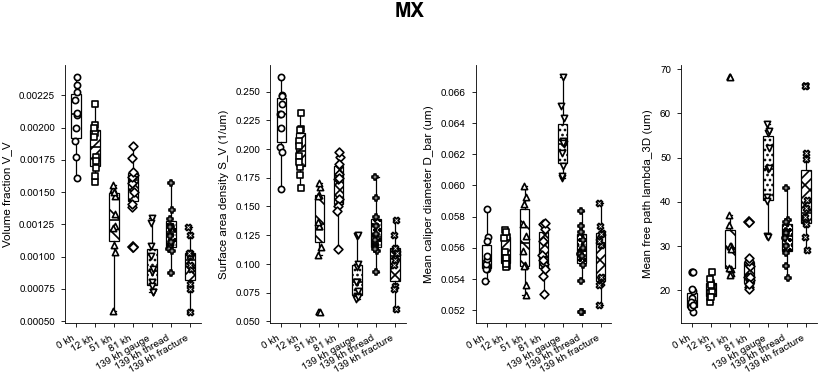

Saved MX -> data\GOO220_image


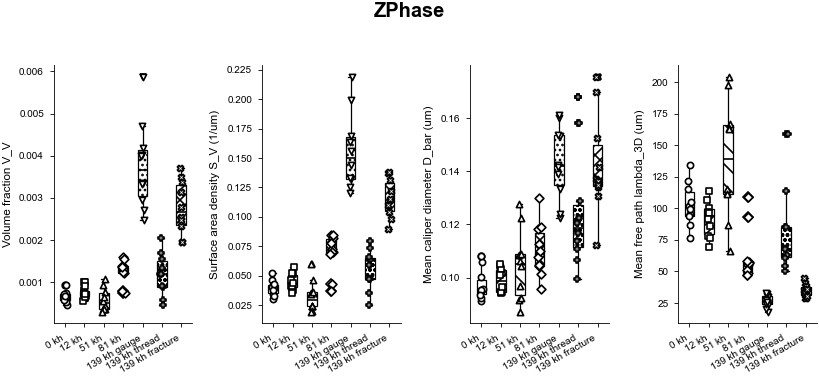

Saved ZPhase -> data\GOO220_image


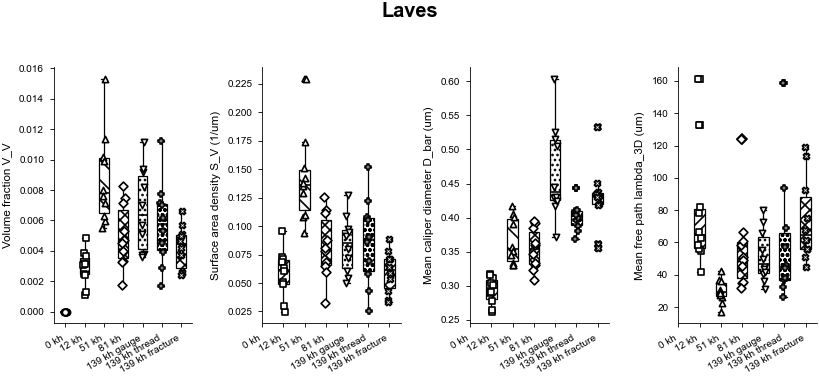

Saved Laves -> data\GOO220_image


In [8]:
for phase in PHASES:
    sub = df_all[df_all["Phase"] == phase]

    with journal_style(NATURE):
        fig, axes = plt.subplots(
            1, len(PLOT_COLS_3D),
            figsize=(180 / 25.4, 180 / 25.4 * 0.45),
            sharey=False,
        )
        rng = np.random.default_rng(42)

        for ax, (col, label) in zip(axes, PLOT_COLS_3D.items()):
            for i, state in enumerate(STATES):
                vals = sub[sub["State"] == state][col].dropna().values
                if len(vals) == 0:
                    continue
                ax.boxplot(
                    vals,
                    positions=[i + 1],
                    widths=0.5,
                    patch_artist=True,
                    boxprops=dict(facecolor="white", hatch=_BW_HATCHES[i % len(_BW_HATCHES)], linewidth=0.75),
                    medianprops=dict(color="black", linewidth=1.0),
                    whiskerprops=dict(color="black", linewidth=0.75),
                    capprops=dict(color="black", linewidth=0.75),
                    flierprops=dict(marker=_BW_MARKERS[i % len(_BW_MARKERS)], markerfacecolor="white",
                                   markeredgecolor="black", markersize=4),
                    manage_ticks=False,
                )
                jitter = rng.uniform(-0.08, 0.08, len(vals))
                ax.scatter(i + 1 + jitter, vals, marker=_BW_MARKERS[i % len(_BW_MARKERS)],
                           facecolors="white", edgecolors="black", s=14, zorder=3)

            ax.set_xticks(range(1, len(STATES) + 1))
            ax.set_xticklabels(
                [STATE_LABELS.get(s, s) for s in STATES], rotation=30, ha="right"
            )
            ax.set_ylabel(label)

        fig.suptitle(f"{phase}", fontweight="bold", y=1.02)
        fig.tight_layout()
        slug = phase.replace(" ", "_")
        save(fig, OUT_DIR / f"boxplot_3d_{slug}", formats=["pdf", "png"])
        plt.show()
        print(f"Saved {phase} -> {OUT_DIR}")

## Next steps

A `stamp.pipeline.run_mipar_image()` orchestrator that wraps loading,
3-D quantity derivation, and multi-state comparison plots into a single
call will be added in a future update.